# Introduction — what question are you answering?


"What actually makes countries happy, and has that changed over time?" 

## Data Loading & Cleaning

In [22]:
import os
print(os.getcwd())

/Users/gunnarcukor/Desktop/world_happiness


In [24]:
import pandas as pd
import os

years = [2015, 2016, 2017, 2018, 2019]
dfs = []

for year in years:
    df = pd.read_csv(f"data/{year}.csv")
    df["year"] = year
    dfs.append(df)

happiness = pd.concat(dfs, ignore_index=True)
print(happiness.shape)
happiness.head()

(782, 31)


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),...,Trust..Government.Corruption.,Dystopia.Residual,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
happiness.columns.tolist()

['Country',
 'Region',
 'Happiness Rank',
 'Happiness Score',
 'Standard Error',
 'Economy (GDP per Capita)',
 'Family',
 'Health (Life Expectancy)',
 'Freedom',
 'Trust (Government Corruption)',
 'Generosity',
 'Dystopia Residual',
 'year',
 'Lower Confidence Interval',
 'Upper Confidence Interval',
 'Happiness.Rank',
 'Happiness.Score',
 'Whisker.high',
 'Whisker.low',
 'Economy..GDP.per.Capita.',
 'Health..Life.Expectancy.',
 'Trust..Government.Corruption.',
 'Dystopia.Residual',
 'Overall rank',
 'Country or region',
 'Score',
 'GDP per capita',
 'Social support',
 'Healthy life expectancy',
 'Freedom to make life choices',
 'Perceptions of corruption']

In [28]:
import pandas as pd

def load_year(year):
    df = pd.read_csv(f"data/{year}.csv")
    df["year"] = year
    
    # Standardize all column names to one clean set
    rename_map = {
        # Country
        "Country or region": "country", "Country": "country",
        # Score
        "Happiness Score": "happiness_score", "Happiness.Score": "happiness_score", "Score": "happiness_score",
        # Rank
        "Happiness Rank": "rank", "Happiness.Rank": "rank", "Overall rank": "rank",
        # GDP
        "Economy (GDP per Capita)": "gdp", "Economy..GDP.per.Capita.": "gdp", "GDP per capita": "gdp",
        # Social support
        "Family": "social_support", "Social support": "social_support",
        # Health
        "Health (Life Expectancy)": "life_expectancy", "Health..Life.Expectancy.": "life_expectancy", "Healthy life expectancy": "life_expectancy",
        # Freedom
        "Freedom": "freedom", "Freedom to make life choices": "freedom",
        # Corruption
        "Trust (Government Corruption)": "corruption", "Trust..Government.Corruption.": "corruption", "Perceptions of corruption": "corruption",
        # Generosity
        "Generosity": "generosity",
        # Region
        "Region": "region",
    }
    
    df = df.rename(columns=rename_map)
    
    # Keep only the columns we care about
    keep = ["country", "year", "rank", "happiness_score", "gdp", 
            "social_support", "life_expectancy", "freedom", "corruption", "generosity", "region"]
    df = df[[col for col in keep if col in df.columns]]
    
    return df

years = [2015, 2016, 2017, 2018, 2019]
happiness = pd.concat([load_year(y) for y in years], ignore_index=True)

print(happiness.shape)
print(happiness.columns.tolist())
happiness.head()

(782, 11)
['country', 'year', 'rank', 'happiness_score', 'gdp', 'social_support', 'life_expectancy', 'freedom', 'corruption', 'generosity', 'region']


,country,year,rank,happiness_score,gdp,social_support,life_expectancy,freedom,corruption,generosity,region
0,Switzerland,2015,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,Western Europe
1,Iceland,2015,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,Western Europe
2,Denmark,2015,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,Western Europe
3,Norway,2015,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,Western Europe
4,Canada,2015,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,North America


In [31]:
happiness.isnull().sum()

country              0
year                 0
rank                 0
happiness_score      0
gdp                  0
social_support       0
life_expectancy      0
freedom              0
corruption           1
generosity           0
region             467
dtype: int64

In [33]:
# Fix 1: Fill the single missing corruption value with the median
happiness["corruption"] = happiness["corruption"].fillna(happiness["corruption"].median())

# Fix 2: Build a country -> region mapping from the rows that DO have region data
region_map = (
    happiness[happiness["region"].notna()]
    .groupby("country")["region"]
    .first()
    .to_dict()
)

# Apply it to fill in the missing regions
happiness["region"] = happiness["region"].fillna(happiness["country"].map(region_map))

# Check how many are still missing
print(happiness.isnull().sum())

country            0
year               0
rank               0
happiness_score    0
gdp                0
social_support     0
life_expectancy    0
freedom            0
corruption         0
generosity         0
region             8
dtype: int64


In [47]:
#see which countries are in the missing region
print(happiness[happiness['region'].isna()]['country'].unique())

#drop them 
happiness = happiness.dropna(subset=['region'])

#confirm we are clean
print(happiness.isnull().sum())
print(happiness.shape)

[]
country            0
year               0
rank               0
happiness_score    0
gdp                0
social_support     0
life_expectancy    0
freedom            0
corruption         0
generosity         0
region             0
dtype: int64
(774, 11)


## Data Loading & Cleaning — Summary
- Loaded 5 yearly CSVs (2015–2019) and standardized inconsistent column names across years
- Merged into a single dataframe of 784 rows × 11 columns
- Filled 1 missing corruption value with the median
- Reconstructed missing region data using a country→region mapping from earlier years
- Dropped 8 countries with no recoverable region data

## Exploratory Analysis


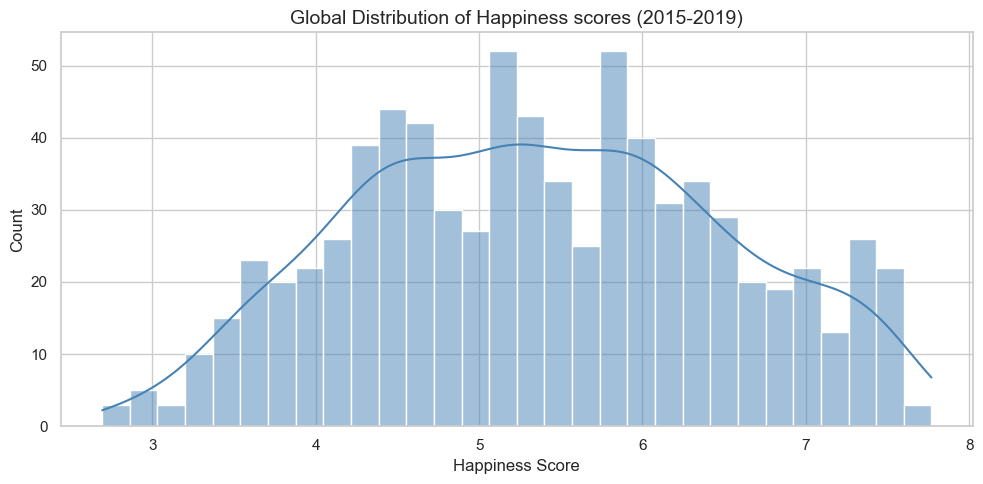

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'whitegrid')

plt.figure(figsize=(10,5))
sns.histplot(happiness['happiness_score'], bins = 30, kde = True, color = 'steelblue')
plt.title('Global Distribution of Happiness scores (2015-2019)', fontsize=14)
plt.xlabel('Happiness Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


The distribution of global happiness scores is roughly bell-shaped, centered around 
5.4, suggesting most countries score in the middle range. There are few extreme 
outliers on either end — truly happy and truly miserable countries are rare.

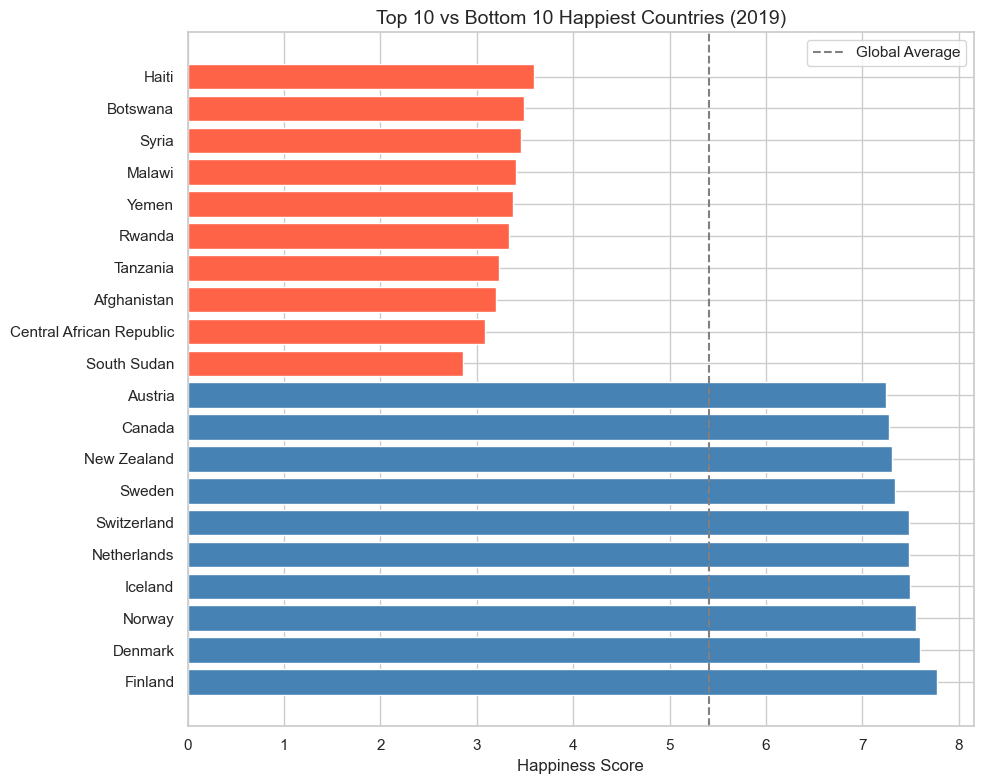

In [54]:
#Use 2019 data only for a clean snapshot
df_2019 = happiness[happiness['year'] == 2019]

top10 = df_2019.nlargest(10, 'happiness_score')
bottom10 = df_2019.nsmallest(10, 'happiness_score')
combined = pd.concat([top10, bottom10])

# color bars differently for top vs bottom
colors = ['steelblue'] * 10 + ['tomato'] * 10

plt.figure(figsize=(10,8))
plt.barh(combined['country'], combined['happiness_score'], color = colors)
plt.axvline(x=df_2019["happiness_score"].mean(), color="gray", linestyle="--", label="Global Average")
plt.title("Top 10 vs Bottom 10 Happiest Countries (2019)", fontsize=14)
plt.xlabel("Happiness Score")
plt.legend()
plt.tight_layout()
plt.show()



The happiest countries in 2019 are dominated by Scandinavian nations (Finland, Denmark, 
Norway, Iceland), suggesting that strong social safety nets and high GDP are associated 
with happiness. The least happy countries are concentrated in Sub-Saharan Africa and 
conflict-affected states like Afghanistan and Haiti, where instability and poverty likely 
suppress wellbeing.

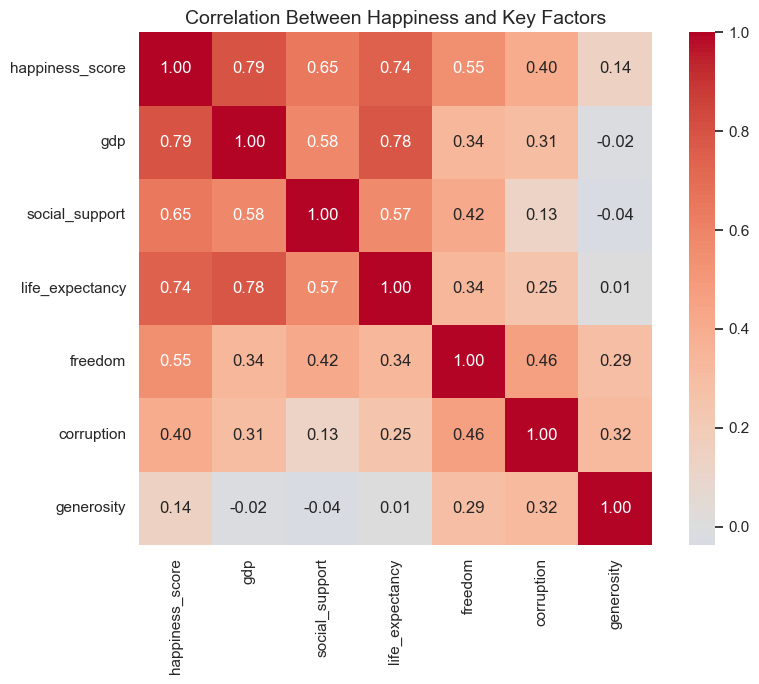

In [63]:
# Select only the numeric columns we care about
corr_cols= ['happiness_score', 'gdp', 'social_support', 'life_expectancy', 'freedom', 'corruption', 'generosity']

corr_matrix = happiness[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, 
            annot=True,          # shows the numbers inside each cell
            fmt=".2f",           # rounds to 2 decimal places
            cmap="coolwarm",     # red = high correlation, blue = low
            center=0,            # centers the color scale at 0
            square=True)         # makes cells square shaped
plt.title("Correlation Between Happiness and Key Factors", fontsize=14)
plt.tight_layout()
plt.show()


GDP, social support, and life expectancy are the strongest predictors of happiness (r > 0.7), suggesting that material wellbeing and community ties matter most. Freedom also shows a moderate positive correlation. Interestingly, generosity and corruption perception have weaker relationships with happiness, implying that how corrupt a government is perceived to be matters less than basic economic and social 
conditions. Notably, most variables are positively correlated with each other, suggesting that wealthy, healthy societies tend to score well across all dimensions.

Note: correlation does not imply causation — high GDP may not directly cause happiness, 
but could reflect broader societal conditions that do.

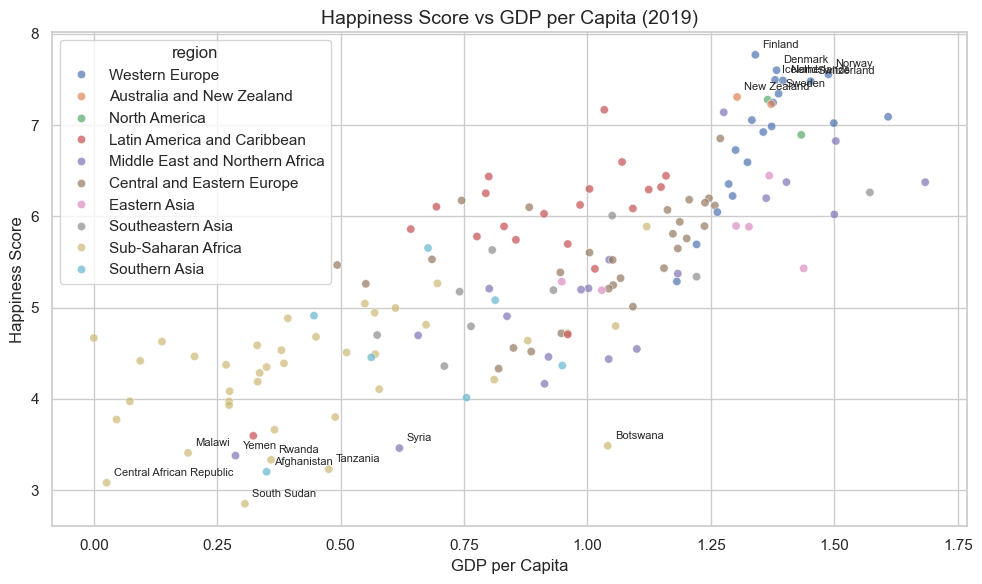

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=happiness[happiness["year"] == 2019], 
                x="gdp", 
                y="happiness_score", 
                hue="region",        # colors dots by region
                alpha=0.7)           # slight transparency so overlapping dots are visible

# Label outliers only (very high or very low happiness)
df_2019 = happiness[happiness["year"] == 2019]
outliers = df_2019[(df_2019["happiness_score"] > 7.3) | (df_2019["happiness_score"] < 3.5)]

for _, row in outliers.iterrows():
    plt.annotate(row["country"], 
                 xy=(row["gdp"], row["happiness_score"]),
                 xytext=(5, 5),           # offset the label slightly so it doesn't overlap the dot
                 textcoords="offset points",
                 fontsize=8)

plt.title("Happiness Score vs GDP per Capita (2019)", fontsize=14)
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

There is a clear positive relationship between GDP per capita and happiness score, consistent with the correlation heatmap (r = 0.79). Countries tend to cluster by region — Western European nations occupy the high GDP, high happiness corner while Sub-Saharan African countries cluster in the lower left. This regional clustering suggests that geography and shared economic/cultural conditions play a significant role in happiness beyond GDP alone.

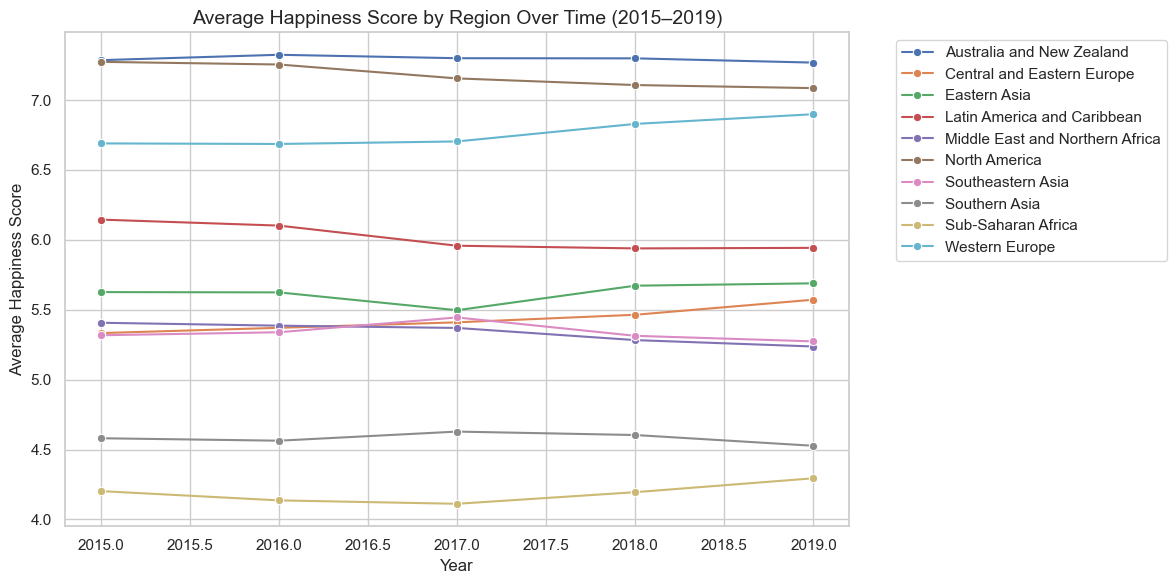

In [77]:
# Calculate average happiness score per region per year
region_trends = happiness.groupby(["year", "region"])["happiness_score"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=region_trends, 
             x="year", 
             y="happiness_score", 
             hue="region",      # separate line per region
             marker="o")        # adds a dot at each data point

plt.title("Average Happiness Score by Region Over Time (2015–2019)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # moves legend outside the chart so it doesn't overlap
plt.tight_layout()
plt.show()

Regional average happiness scores remained largely stable from 2015–2019, with no region showing dramatic shifts. This stability is partly a statistical artifact — averaging across many countries within a region smooths out individual country volatility. A country experiencing conflict or economic crisis may drop significantly, but its effect on the regional average is diluted by neighboring stable countries. Western Europe consistently leads while Sub-Saharan Africa remains at the bottom throughout the period.

/var/folders/hh/7l31dxnn5fb61khx6fl_ytch0000gn/T/ipykernel_72835/4013338270.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=happiness,


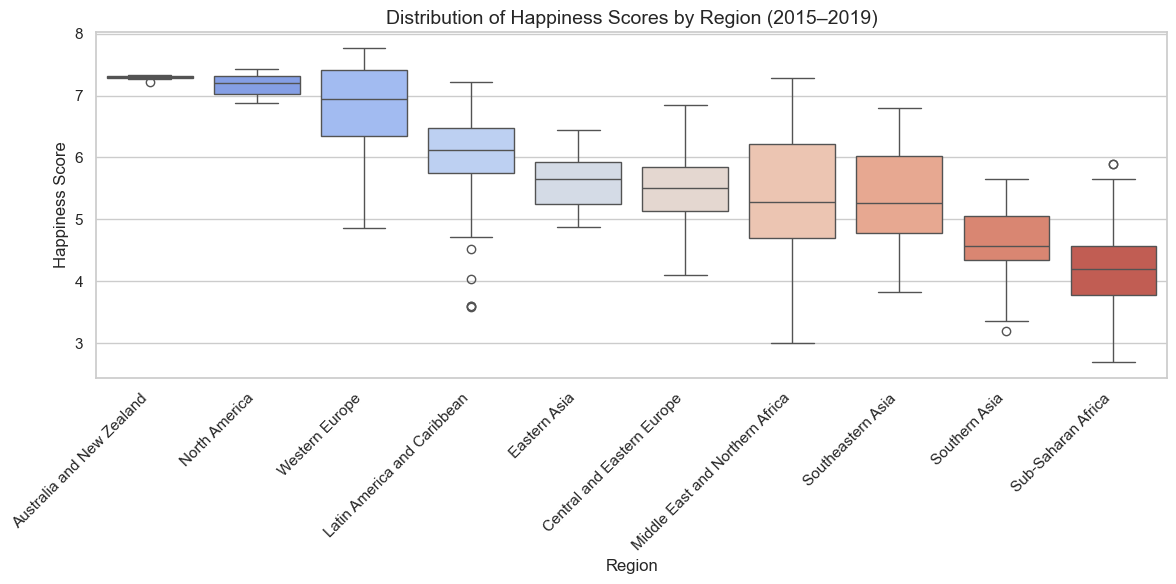

In [82]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=happiness, 
            x="region", 
            y="happiness_score",
            palette="coolwarm",
            order=happiness.groupby("region")["happiness_score"].mean().sort_values(ascending=False).index)

plt.title("Distribution of Happiness Scores by Region (2015–2019)", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Happiness Score")
plt.xticks(rotation=45, ha="right")   # rotates x axis labels so they don't overlap
plt.tight_layout()
plt.show()

Regional box plots reveal significant within-region inequality in happiness that was hidden in the line chart averages. The Middle East & North Africa shows the widest spread, reflecting the stark contrast between wealthy Gulf states (UAE, Qatar) and conflict-affected nations (Yemen, Syria). Southeast Asia similarly spans a wide range from relatively prosperous Singapore to poorer nations like Cambodia. Western Europe's spread is surprising given its reputation for stability — it likely reflects the gap between Northern European nations like Finland and Denmark at the top and Eastern European EU members like Bulgaria and Hungary at the bottom.

## Key Findings


- **GDP, social support, and life expectancy are the strongest predictors of happiness** (r > 0.7), suggesting that economic prosperity and community wellbeing matter
- **Scandinavian nations consistently rank highest** while conflict-affected and economically disadvantaged countries — particularly in Sub-Saharan Africa and the Middle East — cluster at the bottom, reflecting the outsized role of stability and wealth in national wellbeing.far more than moral or institutional factors like corruption perception.
- **Regional averages mask significant within-region inequality.** The Middle East, Southeast Asia, and even Western Europe show wide spreads between their happiest and least happy countries, driven by the contrast between prosperous and crisis-affected states.
- **Global happiness scores remained stable from 2015–2019**, suggesting that national happiness is resilient to short-term changes and likely reflects deep structural conditions rather than year-to-year events.
- **Geography alone does not determine happiness.** While regional clustering exists, outliers in every region suggest that policy choices, governance, and social investment can meaningfully separate countries from their neighbors.

## Conclusion

This study set out to answer: "What actually makes countries happy, and has that changed over time?" Through exploratory analysis of 784 country-year observations across 2015–2019, we found that GDP per capita, social support, and life expectancy are the strongest correlates of national happiness — and that these patterns are remarkably stable over time, suggesting happiness reflects deep structural conditions rather than short-term events.

A key limitation of this analysis is that correlation does not imply causation. Future work could apply causal inference methods to determine whether GDP and social support directly drive happiness or whether both are products of deeper factors like governance quality or cultural values. It would also be valuable to extend the dataset beyond 2019 to examine how events like COVID-19 affected global happiness and whether the stable trends we observed held up under unprecedented global stress.